In [2]:
import glob
import pickle

from tqdm import tqdm


In [6]:

## val
paths = {
    # 'dpp_4': "../runs/internlm/dpp_critic/2025_03_08/02_33_49/traces/0/",
    # 'dpp_3': "../runs/internlm/dpp_critic/2025_03_05/18_40_59/traces/0/",
    # 'dpp_2_1': "../runs/internlm/dpp_critic/2025_03_03/12_57_34/traces/0/",
    # 'cg_1': "../runs/internlm/internlm_cg/2025_03_03/11_50_33/traces/0/",
    # 'cg_2': "../runs/internlm/internlm_cg/2025_03_08/05_15_27/traces/0/",
    # 'cg_3': "../runs/internlm/internlm_cg/2025_03_06/04_23_46/traces/0/",
    # 'bfs_1': "../runs/internlm/internlm/2025_03_15/15_49_16/traces/0/",
    'bfs_2': "../runs/internlm/internlm/2025_03_13/16_14_49/traces/0/",
    # 'dpp_2_2': "../runs/internlm/dpp_critic_k_2/2025_03_19/10_20_24/traces/0/",
    # 'dpp_2_3': "../runs/internlm/dpp_critic_k_2/2025_03_24/10_42_57/traces/0/"
}


In [11]:

paths = {
    # 'leandojo_3dprover_32': "../runs/leandojo_novel_premises/3d_prover-k32/2024_10_29/17_11_25/traces/0/",

    # 'topk_32': "../runs/leandojo_novel_premises/baseline-k32-rFalse/2024_10_29/15_50_40/traces/0/",

    # 'no_filter': "../runs/end_to_end/no_split_a6000-2/2024_05_30/16_08_18/traces/0/"
}


In [3]:
def get_times(path):
    files = glob.glob(path + '*', recursive=True)
    # traces_ = []

    times = []
    for file in tqdm(files):
        try:
            trace = pickle.load(open(file, "rb"))
            if trace.proof:
                times.append(trace.env_time)
        except:
            continue

    return times


In [4]:

trace_times = {}

for key, path in paths.items():
    times = get_times(path)
    trace_times[key] = times

    print(key, sum(trace_times[key]) / len(trace_times[key]))



100%|██████████| 245/245 [00:04<00:00, 59.17it/s]


dpp_4 14.37719598721064


100%|██████████| 245/245 [00:03<00:00, 70.87it/s]


dpp_3 15.077643258970879


100%|██████████| 245/245 [00:03<00:00, 70.84it/s]


...

bfs_1 12.330127786542063


100%|██████████| 245/245 [00:04<00:00, 56.89it/s]


bfs_2 12.135247582976666


0it [00:00, ?it/s]


ZeroDivisionError: division by zero

In [7]:
def get_proven(path):
    files = glob.glob(path + '*', recursive=True)
    # traces_ = []

    proven = []
    proofs = []
    time = []
    for file in tqdm(files):
        try:
            # traces_.append(pickle.load(open(file, "rb")))
            trace = pickle.load(open(file, "rb"))
            if trace.proof:
                proven.append(trace.theorem.full_name)
                proofs.append((trace.theorem.full_name, trace.proof))
                time.append(trace.total_time)
        except:
            # print ('Failed to load:', file)
            continue

    return proven, proofs, time


In [8]:

traces_proved = {}
trace_proofs = {}

for key, path in paths.items():
    proven, proofs, time = get_proven(path)
    traces_proved[key] = proven, time
    trace_proofs[key] = proofs

    print(key, len(traces_proved[key]))



100%|██████████| 245/245 [00:04<00:00, 49.41it/s]

bfs_2 2


In [11]:

def get_proven_traces(path):
    files = glob.glob(path + '*', recursive=True)
    # traces_ = []

    proven = []
    for file in tqdm(files):
        try:
            # traces_.append(pickle.load(open(file, "rb")))
            trace = pickle.load(open(file, "rb"))
            if trace.proof:
                proven.append(trace)
        except:
            # print ('Failed to load:', file)
            continue

    return proven


In [12]:
proven_traces = get_proven_traces(paths['bfs_2'])

100%|██████████| 245/245 [00:05<00:00, 48.32it/s]


<Axes: ylabel='Count'>

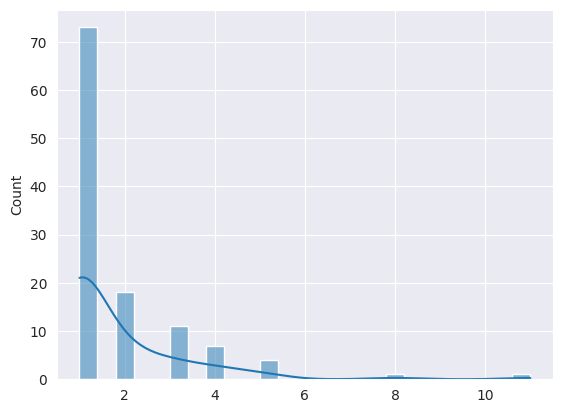

In [14]:
# print length distribution over proofs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

lens = [len(trace.proof) for trace in proven_traces]
sns.histplot(lens, kde=True)




In [16]:

print(len([a for a in lens if a > 2]))

24


In [18]:
test_trace = proven_traces[0]

In [21]:
for e in test_trace.tree.out_edges:
    print(e.tactic, e.tac_logprob, e.dst)

rw [Finset.sum_range_succ] -4.566646104605745 [InternalNode(goal='⊢ (∑ x in Finset.range 100, 2 ^ x + 2 ^ 100) % 7 = 3', _status=<Status.OPEN: 'Open'>)]
norm_num [Finset.sum_range_succ, Finset.sum_range_zero] -3.815940688949894 [ProofFinishedNode(inner=GoalFinished(message=None))]
rw [← Nat.mod_add_div (∑ k in Finset.range -5.190842727884039 [ErrorNode(inner=EnvironmentError(message="<stdin>:1:42: unexpected end of input; expected ','"))]
norm_cast -3.2059847861528397 [ProofFinishedNode(inner=GoalFinished(message=None))]
conv_rhs => rw [← Nat.mod_add_div 3 7] -5.305293941568834 [ProofFinishedNode(inner=GoalFinished(message=None))]
norm_num [Finset.sum_range_succ, Finset.sum_range_succ -1.428687389594387 [ErrorNode(inner=EnvironmentError(message="<stdin>:1:54: unexpected end of input; expected ']'"))]
conv => lhs; rw [← Nat.mod_add_div 101 7] -6.915999642229281 [ProofFinishedNode(inner=GoalFinished(message=None))]
simp only [Finset.sum_range_succ, Finset.sum_range_zero] -5.0590938996001

In [ ]:
# success samples
# simple, just get goal state plus tactic

# error samples
# for every success, look for a (random) failure with the same goal state, and get the tactic, add to state

# backtrack samples
# for every success at depth n > 1, look for path at same depth without proof


# store goal state, tactic / backtrack decision, errors, depth, original goal, tactics so far


# go through trace, find all proof nodes, then can go from there
# success trivial, error just take one at random, backtrack check for sibling if it exists

In [42]:
from experiments.end_to_end.proof_node import ErrorNode, ProofFinishedNode




def get_deepest_children(root):
    # go through tree and map each node to the depth of deepest child

    # get nodes in order via BFS
    to_search = [root]
    nodes = [root]
    visited = set()
    node_depths = {}
    while to_search:
        cur_node = to_search.pop(0)
        if cur_node in visited:
            continue
        visited.add(cur_node)

        if cur_node.out_edges:
            # assumes no subgoal separation
            to_search.extend([e.dst[0] for e in cur_node.out_edges if
                              not isinstance(e.dst[0], ErrorNode) and not isinstance(e.dst[0], ProofFinishedNode) and
                              e.dst[0] not in visited])

            nodes.extend([e.dst[0] for e in cur_node.out_edges if
                          not isinstance(e.dst[0], ErrorNode) and not isinstance(e.dst[0], ProofFinishedNode) and e.dst[
                              0] not in visited])

    # now we have all nodes, go through and get max depth (all children will be filled in as in BFS order)
    for node in nodes[::-1]:
        if not node.out_edges:
            node_depths[node] = 0
        else:
            node_depths[node] = 1 + max([node_depths[e.dst[0]] for e in node.out_edges if
                                         not isinstance(e.dst[0], ErrorNode) and not isinstance(e.dst[0],
                                                                                                ProofFinishedNode) and
                                         e.dst[0] in node_depths] + [0])

    return node_depths






In [116]:
from experiments.end_to_end.proof_node import Status


def get_sft_data(trace):
    proof = trace.proof
    idx = 0

    error_data = []
    success_data = []
    backtrack_data = []

    cur_node = trace.tree
    node_depths = get_deepest_children(cur_node)

    while idx < len(proof):
        cur_tactic = proof[idx]

        success_data.append({
            'cur_goal': cur_node.goal,
            'tactic': cur_tactic,
            'proof_so_far': proof[:idx],
            'original_goal': trace.theorem.full_name,
        })
        # check if there is an error coming from the current node
        if cur_node.out_edges:
            # check if any of the edges are error nodes
            for edge in cur_node.out_edges:
                if isinstance(edge.dst[0], ErrorNode):
                    # check if the error node has the same goal as the current node
                    error_data.append({
                        'cur_goal': cur_node.goal,
                        'tactic': cur_tactic,
                        'proof_so_far': proof[:idx],
                        'original_goal': trace.theorem.full_name,
                        'error_tactic': edge.tactic,
                        'error_message': edge.dst[0].inner.message,
                    })
                    # just take one for now
                    break



        # go to next node
        next_node = [a.dst[0] for a in cur_node.out_edges if a.tactic == cur_tactic][0]

        # check for backtrack data
        if cur_node.out_edges:
            for edge in cur_node.out_edges:
                if not isinstance(edge.dst[0], ErrorNode) and edge.tactic != cur_tactic and edge.dst[0].status != Status.PROVED and edge.dst[0] in node_depths :
                    # for nodes with a direct proof, any open should be backtracked
                    if isinstance(next_node, ProofFinishedNode):
                        backtrack_data.append({
                            'cur_goal': cur_node.goal,
                            'tactic': cur_tactic,
                            'proof_so_far': proof[:idx],
                            'original_goal': trace.theorem.full_name,
                            'backtrack_tactic': edge.tactic,
                            'backtrack_goal': edge.dst[0].goal,
                        })
                        break


                    # otherwise, check if sibling has been explored at least as much as proven node path
                    elif node_depths[edge.dst[0]] >= node_depths[next_node]:
                        backtrack_data.append({
                            'cur_goal': cur_node.goal,
                            'tactic': cur_tactic,
                            'proof_so_far': proof[:idx],
                            'original_goal': trace.theorem.full_name,
                            'backtrack_tactic': edge.tactic,
                            'backtrack_goal': edge.dst[0].goal,
                        })
                        break



        # go to next node
        cur_node = next_node
        idx += 1

    return success_data, error_data, backtrack_data


In [120]:
test_data = get_sft_data(proven_traces[4])

In [121]:
test_data

([{'cur_goal': 'n : ℝ\nh₀ : n = 1 / 3\n⊢ ⌊10 * n⌋ + ⌊100 * n⌋ + ⌊1000 * n⌋ + ⌊10000 * n⌋ = 3702',
   'tactic': 'norm_num [h₀, Int.floor_eq_iff]',
   'proof_so_far': [],
   'original_goal': 'mathd_algebra_153'},
  {'cur_goal': 'n : ℝ\nh₀ : n = 1 / 3\n⊢ ⌊10 / 3⌋ + ⌊100 / 3⌋ + ⌊1000 / 3⌋ + ⌊10000 / 3⌋ = 3702',
   'tactic': 'rw [h₀] at *',
   'proof_so_far': ['norm_num [h₀, Int.floor_eq_iff]'],
   'original_goal': 'mathd_algebra_153'},
  {'cur_goal': 'n : ℝ\nh₀ : 1 / 3 = 1 / 3\n⊢ ⌊10 / 3⌋ + ⌊100 / 3⌋ + ⌊1000 / 3⌋ + ⌊10000 / 3⌋ = 3702',
   'tactic': 'rw [← Int.cast_ofNat]',
   'proof_so_far': ['norm_num [h₀, Int.floor_eq_iff]', 'rw [h₀] at *'],
   'original_goal': 'mathd_algebra_153'},
  {'cur_goal': 'n : ℝ\nh₀ : 1 / 3 = 1 / 3\n⊢ ⌊↑10 / 3⌋ + ⌊100 / 3⌋ + ⌊1000 / 3⌋ + ⌊10000 / 3⌋ = 3702',
   'tactic': 'rw [← Int.cast_ofNat]',
   'proof_so_far': ['norm_num [h₀, Int.floor_eq_iff]',
    'rw [h₀] at *',
    'rw [← Int.cast_ofNat]'],
   'original_goal': 'mathd_algebra_153'},
  {'cur_goal': 'n : ℝ\

In [119]:
# backtrack if any siblings have max depth >= proven sibling, or siblings depth >= proof depth - cur_depth (i.e. have gone at least as deep in sibling as closest proof)

# case for multiple proofs with different lengths at same depth? Only backtrack if further than longest proof from current point..

# simplest is to backtrack at depth 1 for leaf proof vs sibling, otherwise look for simple condition sibling max_depth vs depth of proven sibling

test_tree = proven_traces[3].tree

test = get_deepest_children(test_tree)
for t in test:
    print(t.status, test[t], t.depth)

Status.OPEN 0 1
Status.PROVED 1 1
Status.OPEN 0 1
Status.PROVED 2 0


In [9]:
traces_proved

{'bfs_2': (['mathd_numbertheory_127',
   'mathd_algebra_354',
   'imo_1964_p2',
   'mathd_algebra_441',
   'mathd_algebra_153',
   'mathd_algebra_80',
   'mathd_numbertheory_233',
   'mathd_algebra_139',
   'algebra_sqineq_at2malt1',
   'mathd_algebra_392',
   'mathd_algebra_107',
   'mathd_algebra_427',
   'mathd_algebra_329',
   'mathd_algebra_302',
   'mathd_numbertheory_247',
   'mathd_algebra_270',
   'induction_11div10tonmn1ton',
   'mathd_numbertheory_345',
   'mathd_algebra_419',
   'mathd_numbertheory_239',
   'mathd_numbertheory_100',
   'aime_1989_p8',
   'mathd_numbertheory_254',
   'mathd_algebra_440',
   'mathd_algebra_246',
   'mathd_algebra_412',
   'amc12b_2002_p19',
   'mathd_numbertheory_765',
   'mathd_algebra_44',
   'mathd_numbertheory_66',
   'mathd_numbertheory_582',
   'mathd_numbertheory_559',
   'mathd_numbertheory_353',
   'induction_12dvd4expnp1p20',
   'mathd_numbertheory_314',
   'mathd_algebra_125',
   'mathd_numbertheory_207',
   'mathd_algebra_113',
  

In [9]:
# get the intersection of proved theorems, and number unique to each set

traces_proved = {key: (set(value[0]), value[1]) for key, value in traces_proved.items()}

In [10]:

for key, value in traces_proved.items():
    print(key, len(value[0]))


dpp_4 117
dpp_3 115
dpp_2_1 115
cg_1 107
cg_2 113
cg_3 113
bfs_1 103
bfs_2 115
dpp_2_2 115
dpp_2_3 109


In [15]:
len([a for a in traces_proved['bestfs_8_top'][1] if a <= 600])

52

In [17]:
len([a for a in traces_proved['k8'][1] if a <= 600])

58

In [50]:
for key, value in traces_proved.items():
    print(key, len([a for a in value[1] if a <= 830]) / 244)

bestfs_8_top 0.21721311475409835
k8 0.23770491803278687
bestfs 0.2786885245901639
bestfs_8_random 0.1885245901639344
bestfs_16_top 0.26639344262295084
bestfs_16_random 0.24180327868852458
bestfs_32_top 0.2786885245901639
bestfs_32_random 0.27459016393442626
k16 0.2786885245901639
k32 0.2786885245901639


In [31]:
67 / 244


0.27459016393442626

In [32]:
67 / 66

1.0151515151515151

In [ ]:
import numpy as np

print(np.mean([len(value) / 245 for key, value in traces_proved.items() if '32' in key]))
print(np.std([len(value) / 245 for key, value in traces_proved.items() if '32' in key]))




In [57]:

proof_lens = {}

for k, v in trace_proofs.items():
    lens = []
    for proof in v:
        lens.append(len(proof[1]))
    proof_lens[k] = lens



In [58]:

# map proof name to minimum length over all keys

min_lens = {}

for key, proofs in trace_proofs.items():
    for proof in proofs:
        if proof[0] not in min_lens:
            min_lens[proof[0]] = len(proof[1])
        elif len(proof[1]) < min_lens[proof[0]]:
            min_lens[proof[0]] = len(proof[1])
# update proof length to be the minimum found 
for k, v in proof_lens.items():
    proof_lens[k] = [min_lens[proof[0]] for proof in trace_proofs[k]]



In [38]:
proof_lens

{'leandojo_3dprover_32': [5,
  1,
  2,
  1,
  1,
  4,
  2,
  4,
  1,
  3,
  3,
  3,
  2,
  1,
  1,
  1,
  1,
  2,
  1,
  3,
  3,
  1,
  4,
  2,
  4,
  2,
  2,
  4,
  1,
  4,
  1,
  2,
  3,
  1,
  4,
  3,
  3,
  3,
  4,
  2,
  1,
  1,
  1,
  2,
  1,
  2,
  2,
  3,
  1,
  3,
  2,
  2,
  1,
  1,
  2,
  3,
  3,
  2,
  2,
  2,
  3,
  1,
  1,
  5,
  2,
  1,
  3,
  1,
  3,
  1,
  4,
  3,
  3,
  2,
  2,
  2,
  2,
  3,
  3,
  2,
  5,
  2,
  3,
  3,
  4,
  5,
  2,
  1,
  1,
  5,
  5,
  1,
  4,
  1,
  3,
  2,
  1,
  2,
  3,
  6,
  2,
  2,
  3,
  1,
  2,
  2,
  3,
  1,
  3,
  2,
  1,
  2,
  2,
  1,
  4,
  3,
  4,
  5,
  2,
  1,
  1,
  6,
  3,
  1,
  3,
  3,
  1,
  1,
  3,
  5,
  2,
  2,
  1,
  3,
  1,
  2,
  2,
  4,
  3,
  1,
  1,
  2,
  1,
  1,
  2,
  6,
  2,
  5,
  3,
  3,
  3,
  4,
  1,
  1,
  2,
  2,
  1,
  2,
  4,
  1,
  1,
  1,
  1,
  1,
  1,
  4,
  2,
  3,
  2,
  1,
  3,
  1,
  3,
  3,
  3,
  2,
  4,
  1,
  2,
  2,
  1,
  1,
  1,
  1,
  3,
  2,
  1,
  3,
  2,
  2,
  3,
  1,
  1,
  2,
  1,
 

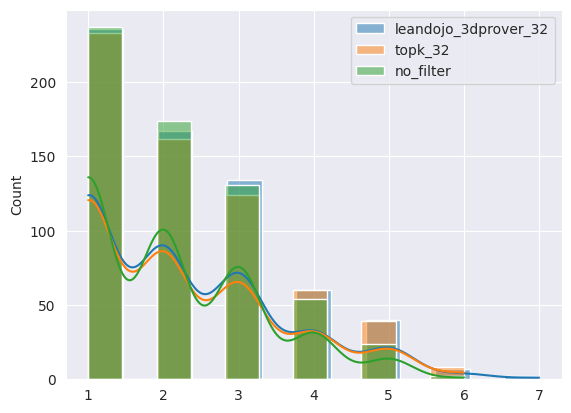

In [48]:

# plot all the proof lengths with a histogram and legend, with each key side by side in plot, using seaborn

import seaborn as sns

import matplotlib.pyplot as plt

for key, lens in proof_lens.items():
    sns.histplot(lens, label=key, kde=True)
plt.legend()
plt.show()




In [50]:
# for each length from 1 to max length, get the number of proofs of that length for each key

table = {i: [(k, len([a for a in lens if a == i])) for k, lens in proof_lens.items()] for i in range(1, 8)}
table





{1: [('leandojo_3dprover_32', 236), ('topk_32', 233), ('no_filter', 237)],
 2: [('leandojo_3dprover_32', 167), ('topk_32', 162), ('no_filter', 174)],
 3: [('leandojo_3dprover_32', 134), ('topk_32', 124), ('no_filter', 131)],
 4: [('leandojo_3dprover_32', 60), ('topk_32', 60), ('no_filter', 54)],
 5: [('leandojo_3dprover_32', 40), ('topk_32', 39), ('no_filter', 24)],
 6: [('leandojo_3dprover_32', 7), ('topk_32', 8), ('no_filter', 2)],
 7: [('leandojo_3dprover_32', 2), ('topk_32', 0), ('no_filter', 0)]}

In [74]:
# for each length from 1 to max length, get the number of proofs of that length for each key

table = {i: [(k, len([a for a in lens if a == i])) for k, lens in proof_lens.items()] for i in range(1, 7)}
table






{1: [('bestfs', 42),
  ('bestfs_8_top', 40),
  ('bestfs_16_top', 41),
  ('bestfs_32_top', 42),
  ('k16', 42),
  ('k8', 41),
  ('k32', 42)],
 2: [('bestfs', 14),
  ('bestfs_8_top', 8),
  ('bestfs_16_top', 11),
  ('bestfs_32_top', 13),
  ('k16', 13),
  ('k8', 10),
  ('k32', 13)],
 3: [('bestfs', 11),
  ('bestfs_8_top', 4),
  ('bestfs_16_top', 8),
  ('bestfs_32_top', 9),
  ('k16', 9),
  ('k8', 7),
  ('k32', 10)],
 4: [('bestfs', 0),
  ('bestfs_8_top', 0),
  ('bestfs_16_top', 2),
  ('bestfs_32_top', 3),
  ('k16', 3),
  ('k8', 1),
  ('k32', 4)],
 5: [('bestfs', 1),
  ('bestfs_8_top', 0),
  ('bestfs_16_top', 1),
  ('bestfs_32_top', 0),
  ('k16', 1),
  ('k8', 1),
  ('k32', 0)],
 6: [('bestfs', 0),
  ('bestfs_8_top', 1),
  ('bestfs_16_top', 2),
  ('bestfs_32_top', 1),
  ('k16', 2),
  ('k8', 1),
  ('k32', 1)]}

In [71]:
[k for k, v in min_lens.items() if v == 8]

['induction_divisibility_9div10tonm1']

In [ ]:
# def pass_at_k(n, c, k):
#     """
#     :param n: total number of samples
#     :param c: number of correct samples
#     :param k: k in pass@$k$
#     """
#     if n - c < k:
#         return 1.0
#     return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))

In [24]:
# get the union (pass@k) over sets

union = traces_proved['dpp_2_1'][0].union(
    traces_proved['dpp_3'][0],
    traces_proved['dpp_4'][0],
    # traces_proved['bfs_1'][0],
    # traces_proved['bfs_2'][0],
)

# 44, 56, 61, 63
print(len(union) / 245)

import numpy as np

# calculate mean and std error with sem package
dpp_vals = ['dpp_2_1', 'dpp_3', 'dpp_4']

mean = np.mean([len(traces_proved[val][0]) / 245 for val in dpp_vals])
sem = np.std([len(traces_proved[val][0]) / 245 for val in dpp_vals]) / np.sqrt(len(dpp_vals))
print(mean, sem)







0.5142857142857142
0.472108843537415 0.0022217594038849656


In [25]:
# get the union (pass@k) over sets

union = traces_proved['cg_1'][0].union(
    traces_proved['cg_2'][0],
    traces_proved['cg_3'][0],
    # traces_proved['bfs_1'][0],
    # traces_proved['bfs_2'][0],
)

# 44, 56, 61, 63
print(len(union) / 245)

cg_vals = ['cg_1', 'cg_2', 'cg_3']

mean = np.mean([len(traces_proved[val][0]) / 245 for val in cg_vals])
sem = np.std([len(traces_proved[val][0]) / 245 for val in cg_vals]) / np.sqrt(len(cg_vals))
print(mean, sem)

0.5020408163265306
0.45306122448979586 0.006665278211654896


In [21]:
126 / 245

0.5142857142857142

In [15]:
# get the union (pass@k) over sets

union = traces_proved['cg_1'][0].union(
    traces_proved['cg_2'][0],
    traces_proved['cg_3'][0],
    traces_proved['bfs_1'][0],
    traces_proved['bfs_2'][0],
)

# 44, 56, 61, 63
len(union)

129

In [16]:
# get the union (pass@k) over sets

union = traces_proved['bfs_1'][0].union(
    traces_proved['bfs_2'][0],
    traces_proved['cg_3'][0],
    traces_proved['bfs_1'][0],
    traces_proved['bfs_2'][0],
)

# 44, 56, 61, 63
len(union)

119

In [147]:
a = [44, 56, 61, 63]
[i / 245 for i in a]

[0.17959183673469387,
 0.22857142857142856,
 0.24897959183673468,
 0.2571428571428571]

In [120]:
union = traces_proved['bestfs_16_1'].union(
    traces_proved['bestfs_16_2'],
    traces_proved['bestfs_16_3'],
    traces_proved['bestfs_16_4'],
)
len(union)

# 52, 70, 72, 74


74

In [148]:
a = [52, 70, 72, 74]
[i / 245 for i in a]

[0.21224489795918366,
 0.2857142857142857,
 0.2938775510204082,
 0.3020408163265306]

In [127]:
union = traces_proved['bestfs_32_1'].union(
    traces_proved['bestfs_32_2'],
    traces_proved['bestfs_32_3'],
    # traces_proved['bestfs_32_4'],
)
len(union)

# 69, 71, 73, 73


73

In [149]:
a = [69, 71, 73, 73]
[i / 245 for i in a]

[0.2816326530612245,
 0.2897959183673469,
 0.2979591836734694,
 0.2979591836734694]

In [131]:
union = traces_proved['dpp_8_1'].union(
    traces_proved['dpp_8_2'],
    traces_proved['dpp_8_3'],
    traces_proved['dpp_8_4'],

)
len(union)

# 61, 64, 65, 70


70

In [150]:
a = [61, 64, 65, 70]
[i / 245 for i in a]

[0.24897959183673468,
 0.2612244897959184,
 0.2653061224489796,
 0.2857142857142857]

In [139]:
union = traces_proved['dpp_16_1'].union(
    traces_proved['dpp_16_2'],
    traces_proved['dpp_16_3'],
    traces_proved['dpp_16_4'],
)
len(union)

# 68, 72, 73, 76


76

In [151]:
a = [68, 72, 73, 76]
[i / 245 for i in a]


[0.27755102040816326,
 0.2938775510204082,
 0.2979591836734694,
 0.31020408163265306]

In [145]:
union = traces_proved['dpp_32_1'].union(
    traces_proved['dpp_32_2'],
    traces_proved['dpp_32_3'],
    traces_proved['dpp_32_4'],
)

len(union)

# 70, 71, 73, 73


73

In [152]:
a = [70, 71, 73, 73]
[i / 245 for i in a]

[0.2857142857142857,
 0.2897959183673469,
 0.2979591836734694,
 0.2979591836734694]

In [88]:
trace_proofs.values()




dict_values([[('mathd_numbertheory_127', ['norm_num', 'symmetry', 'norm_num [<a>finset.sum_range_succ</a>]']), ('mathd_algebra_354', ['linarith']), ('mathd_algebra_441', ['field_simp', 'ring']), ('mathd_algebra_80', ['contrapose! h₁', 'contrapose! h₀', 'exfalso', 'rw [<a>div_eq_iff</a>] at h₀', 'apply h₁', 'linarith', 'intro hx', 'simpa [hx] using h₀']), ('mathd_algebra_139', ['norm_num [h₀, h₀]']), ('mathd_algebra_107', ['rw [<a>sq</a>, <a>sq</a>, <a>sq</a>]', 'abel', 'linear_combination h₀']), ('mathd_algebra_427', ['rwa <a>add_comm</a> at h₀ h₁', 'linarith']), ('mathd_algebra_329', ['linarith']), ('mathd_algebra_302', ['simp [<a>complex.I_sq</a>]', 'norm_num']), ('mathd_numbertheory_247', ['revert h₀', 'rw <a>nat.mul_mod</a>', 'cases <a>nat.mod_two_eq_zero_or_one</a> n', 'simp [h, <a>nat.mul_mod</a>]', 'simp [h, <a>nat.odd_of_mod_four_eq_three</a>]']), ('mathd_algebra_270', ['classical', 'norm_num [h₀]']), ('mathd_numbertheory_345', ['norm_num']), ('mathd_algebra_419', ['rw [h₀]', '

In [114]:
baseline_union = traces_proved['bestfs_8_1'].union(
    traces_proved['bestfs_8_2'],
    traces_proved['bestfs_8_3'],
    traces_proved['bestfs_8_4'],

    traces_proved['bestfs_16_1'],
    traces_proved['bestfs_16_2'],
    traces_proved['bestfs_16_3'],
    traces_proved['bestfs_16_4'],

    traces_proved['bestfs_32_1'],
    traces_proved['bestfs_32_2'],
    traces_proved['bestfs_32_3'],

    traces_proved['bestfs_8_top'],
    traces_proved['bestfs_16_top'],
    traces_proved['bestfs_32_top'],

)


In [115]:
len(baseline_union)

77

In [116]:
dpp_union = traces_proved['dpp_8_1'].union(

    traces_proved['dpp_8_2'],
    traces_proved['dpp_8_3'],
    traces_proved['dpp_8_4'],

    traces_proved['dpp_16_1'],
    traces_proved['dpp_16_2'],
    traces_proved['dpp_16_3'],
    traces_proved['dpp_16_4'],

    traces_proved['dpp_32_1'],
    traces_proved['dpp_32_2'],
    traces_proved['dpp_32_3'],
    traces_proved['dpp_32_4'],

)

AttributeError: 'list' object has no attribute 'union'

In [117]:
len(dpp_union)

77

In [118]:
baseline_union.difference(dpp_union)


{'mathd_algebra_296'}

In [119]:

dpp_union.difference(baseline_union)


{'induction_12dvd4expnp1p20'}

In [121]:
shortest_proofs = {}

for key, proofs in trace_proofs.items():
    for proof in proofs:
        if proof[0] not in shortest_proofs:
            shortest_proofs[proof[0]] = proof[1]
        elif len(proof[1]) < len(shortest_proofs[proof[0]]):
            shortest_proofs[proof[0]] = proof[1]

In [122]:
len(shortest_proofs)

78

In [123]:
lens = [len(s) for s in shortest_proofs.values()]

# show table of values of lens, from 1 to 5

table = {i: len([a for a in lens if a == i]) for i in range(1, 6)}
table


{1: 47, 2: 19, 3: 6, 4: 3, 5: 3}

In [87]:
len([a for a in lens if a == 5])

4

In [133]:
long_proofs = [k for k, a in shortest_proofs.items() if len(a) >= 4]

In [135]:
len(long_proofs)

6

In [134]:
baseline_count = 0
dpp_count = 0

for l in long_proofs:
    if l in baseline_union:
        baseline_count += 1
    if l in dpp_union:
        dpp_count += 1

print(baseline_count, dpp_count)

5 6


In [131]:
for key, proofs in trace_proofs.items():
    for proof in proofs:
        if 'mathd_algebra_296' == proof[0] or 'imo_1968_p5_1' == proof[0] or 'induction_12dvd4expnp1p20' == proof[0]:
            print(key, proof)



bestfs_32_1 ('mathd_algebra_296', ['rw [<a>abs_sub_comm</a>, <a>abs_of_nonneg</a>]', 'norm_num [<a>sq</a>]', 'linarith'])
dpp_8_4 ('induction_12dvd4expnp1p20', ['cases n', 'norm_num', "simp [<a>pow_succ'</a>]", 'transitivity', 'apply <a>nat.dvd_of_mod_eq_zero</a>', 'rw <a>nat.mod_def</a>', 'norm_num', 'norm_num'])
dpp_8_4 ('imo_1968_p5_1', ['use 0', 'simp [h₁]', "have h₀' : 0 < 1/2", 'norm_num', "norm_num at h₀'"])
dpp_16_1 ('induction_12dvd4expnp1p20', ['transitivity', 'apply <a>nat.dvd_of_mod_eq_zero</a>', 'rw <a>nat.mod_def</a>', 'norm_num', 'norm_num'])
dpp_16_2 ('imo_1968_p5_1', ["have h₀' : 0 < 1/2", 'contrapose! h₀', 'linarith', 'use 1', "norm_num at h₀'"])
dpp_16_3 ('imo_1968_p5_1', ['use 0', 'simp', "have h₀' : 0 < 1/2", 'contrapose! h₀', 'linarith', "norm_num at h₀'"])
dpp_32_3 ('imo_1968_p5_1', ['use 0', 'simp [h₁]', "have h₀' : 0 < 1/2", 'norm_num', "norm_num at h₀'"])
bestfs_8_top ('imo_1968_p5_1', ['use 0', 'simp [h₁]', "have h₀' : 0 < 1/2", 'norm_num', "norm_num at h₀'"]

In [ ]:
union = traces_proved['k16'].union(
    # traces_proved['k16'],
    # traces_proved['k8'],
    # traces_proved['k32_e0.5'],
    traces_proved['k16_e0.5'],
    # traces_proved['k8_e0.5'],
    # traces_proved['k32_t1'],
    traces_proved['k16_t1'],
    # traces_proved['k8_t1'],
    # traces_proved['k32_theta4'],
    traces_proved['k16_theta4'],
    # traces_proved['k8_theta4'],
    # traces_proved['k32_e0.1'],
    traces_proved['k16_e0.1'],
    # traces_proved['k8_e0.1'],
)

len(union)


In [ ]:

union = traces_proved['bestfs_8_top'].union(
    traces_proved['bestfs_8_random'],
    traces_proved['bestfs_16_top'],
    traces_proved['bestfs_16_random'],
    traces_proved['bestfs_32_top'],
    traces_proved['bestfs_32_random'],
)
len(union)